# SK Hynix Defect Test Prediction — v3

**변경사항 (vs v1)**
- Optuna로 LightGBM 하이퍼파라미터 자동 탐색 (100 trials)
- 피처는 v1 기준 (315개, 글로벌 집계) — v2 실험에서 Step별 피처 추가가 효과 없었으므로

**목표 RMSE: ~40**

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_DIR = '문제1(하)/'
ANS_DIR  = '문제1_하_answer/'
WF_ID    = 'C64'
TARGET   = 'C65'

## 1. 데이터 로드

In [3]:
train = pd.read_csv(DATA_DIR + 'train_data.csv')
valid_X = pd.read_csv(DATA_DIR + 'valid_X.csv')
test_X  = pd.read_csv(DATA_DIR + 'test_X.csv')

valid_Y_prob = pd.read_csv(DATA_DIR + 'valid_Y_problem.csv')
test_Y_prob  = pd.read_csv(DATA_DIR + 'test_Y_problem.csv')

valid_Y_ans = pd.read_csv(ANS_DIR + 'valid_Y_answer.csv')
test_Y_ans  = pd.read_csv(ANS_DIR + 'test_Y_answer.csv')

print(f"train: {train.shape}, valid_X: {valid_X.shape}, test_X: {test_X.shape}")

train: (123614, 65), valid_X: (20577, 64), test_X: (20510, 64)


## 2. 전처리

In [4]:
DROP_IDS      = ['C34', 'C35', 'C38']
DROP_LOT_IDS  = ['C20', 'C21', 'C22']
DROP_CONST    = ['C14', 'C24']
DROP_EXCLUDE  = ['C26', 'C28', 'C29', 'C37']
DROP_ALLNA    = ['C2', 'C13', 'C43', 'C47', 'C53', 'C55']
DROP_TIME_RAW = ['C10', 'C39', 'C40']

DROP_ALL = DROP_IDS + DROP_LOT_IDS + DROP_CONST + DROP_EXCLUDE + DROP_ALLNA + DROP_TIME_RAW

train_cols_no_target = [c for c in train.columns if c != TARGET]
valid_X = valid_X[train_cols_no_target]
test_X  = test_X[train_cols_no_target]

meta_cols = set([WF_ID] + DROP_ALL + ['C6', 'C7', 'C41', 'C33'])
SENSOR_COLS = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in meta_cols and c != TARGET]
print(f"FDC 센서 컬럼 수: {len(SENSOR_COLS)}")

FDC 센서 컬럼 수: 36


## 3. Feature Engineering (v1 동일)

In [5]:
def compute_slope(series):
    y = series.dropna().values
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y), dtype=np.float64)
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def extract_wf_features(df, has_target=True):
    groups = df.groupby(WF_ID)

    # 수치형 FDC 센서 집계
    agg_df = groups[SENSOR_COLS].agg(['mean', 'std', 'min', 'max', 'median'])
    agg_df.columns = [f"{c}_{fn}" for c, fn in agg_df.columns]

    range_df = groups[SENSOR_COLS].apply(lambda x: x.max() - x.min())
    range_df.columns = [f"{c}_range" for c in SENSOR_COLS]

    delta_df = groups[SENSOR_COLS].apply(lambda x: x.iloc[-1] - x.iloc[0])
    delta_df.columns = [f"{c}_delta" for c in SENSOR_COLS]

    slope_df = groups[SENSOR_COLS].apply(lambda x: x.apply(compute_slope))
    slope_df.columns = [f"{c}_slope" for c in SENSOR_COLS]

    # 메타
    meta_df = pd.DataFrame(index=groups.groups.keys())
    meta_df['n_rows'] = groups.size()
    meta_df['C41_total'] = groups['C41'].max()
    meta_df['C33_first'] = groups['C33'].first()
    meta_df['C33_max'] = groups['C33'].max()

    # C6 비율
    if 'C6' in df.columns:
        c6_dum = pd.get_dummies(df[[WF_ID, 'C6']].set_index(WF_ID)['C6'], prefix='C6')
        c6_feat = c6_dum.groupby(level=0).mean()
    else:
        c6_feat = pd.DataFrame(index=groups.groups.keys())

    # C7 비율
    if 'C7' in df.columns:
        c7_dum = pd.get_dummies(df[[WF_ID, 'C7']].astype(str).set_index(WF_ID)['C7'], prefix='C7')
        c7_feat = c7_dum.groupby(level=0).mean()
    else:
        c7_feat = pd.DataFrame(index=groups.groups.keys())

    features = pd.concat([agg_df, range_df, delta_df, slope_df, meta_df, c6_feat, c7_feat], axis=1)
    features.index.name = WF_ID
    features = features.reset_index()

    if has_target:
        target_df = groups[TARGET].first().reset_index()
        features = features.merge(target_df, on=WF_ID)

    return features

print("extract_wf_features 정의 완료")

extract_wf_features 정의 완료


## 4. 피처 추출

In [6]:
%%time
print("Train 피처 추출 중...")
train_feat = extract_wf_features(train, has_target=True)
print(f"  → {train_feat.shape}")

print("Valid 피처 추출 중...")
valid_feat = extract_wf_features(valid_X, has_target=False)
print(f"  → {valid_feat.shape}")

print("Test 피처 추출 중...")
test_feat = extract_wf_features(test_X, has_target=False)
print(f"  → {test_feat.shape}")

Train 피처 추출 중...
  → (11939, 301)
Valid 피처 추출 중...
  → (1990, 300)
Test 피처 추출 중...
  → (1990, 300)
CPU times: total: 4min 45s
Wall time: 4min 46s


## 5. 피처/타깃 분리

In [7]:
feature_cols = [c for c in train_feat.columns if c not in [WF_ID, TARGET]]
common_cols = sorted(set(feature_cols) & set(valid_feat.columns) & set(test_feat.columns))
print(f"공통 피처 수: {len(common_cols)}")

X_train = train_feat[common_cols].values
y_train = train_feat[TARGET].values
wf_train = train_feat[WF_ID].values

X_valid = valid_feat[common_cols].values
X_test  = test_feat[common_cols].values
wf_valid = valid_feat[WF_ID].values
wf_test  = test_feat[WF_ID].values

valid_answer = valid_Y_ans.set_index('C64').loc[wf_valid, 'C65'].values
test_answer  = test_Y_ans.set_index('C64').loc[wf_test, 'C65'].values

wf_to_int = {wf: i for i, wf in enumerate(np.unique(wf_train))}
cv_groups = np.array([wf_to_int[wf] for wf in wf_train])

print(f"X_train: {X_train.shape}")

공통 피처 수: 299
X_train: (11939, 299)


## 6. Optuna 하이퍼파라미터 탐색

100 trial로 LightGBM 최적 파라미터를 탐색합니다.
탐색 범위:
- learning_rate: 0.005 ~ 0.3
- num_leaves: 15 ~ 255
- min_child_samples: 5 ~ 100
- subsample: 0.5 ~ 1.0
- colsample_bytree: 0.3 ~ 1.0
- reg_alpha: 1e-3 ~ 100
- reg_lambda: 1e-3 ~ 100
- max_depth: 3 ~ 12 또는 제한 없음

In [8]:
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)


def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        'n_estimators': 3000,

        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 100, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 100, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 7),
    }

    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, cv_groups)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(0),
            ]
        )

        pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        fold_scores.append(rmse)

    return np.mean(fold_scores)


print("Optuna 탐색 시작 (100 trials)...")
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    study_name='lgbm_v3'
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n최적 CV RMSE: {study.best_value:.4f}")
print(f"v1 CV RMSE:    62.88")
print(f"개선:          {62.88 - study.best_value:+.4f}")
print(f"\n최적 파라미터:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Optuna 탐색 시작 (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


최적 CV RMSE: 62.2011
v1 CV RMSE:    62.88
개선:          +0.6789

최적 파라미터:
  learning_rate: 0.005759888493722243
  num_leaves: 189
  max_depth: 10
  min_child_samples: 14
  subsample: 0.9668278565281413
  colsample_bytree: 0.6553280106987178
  reg_alpha: 4.25633536843975
  reg_lambda: 0.003098395985992314
  min_split_gain: 0.7576030443171627
  subsample_freq: 6


## 7. 튜닝 과정 시각화

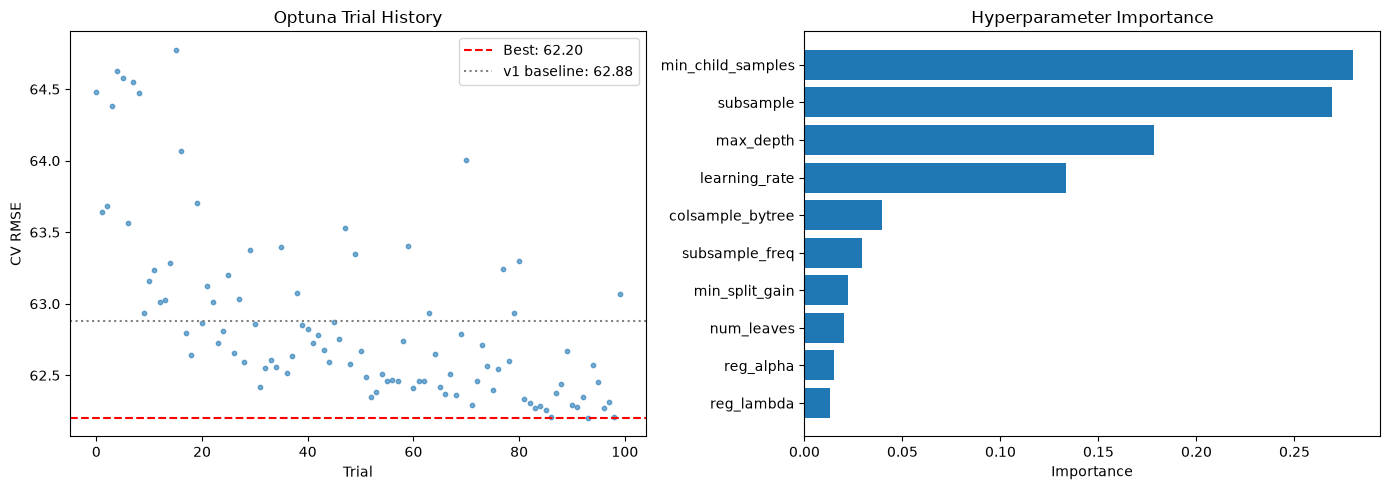

In [9]:
import matplotlib.pyplot as plt

# Trial별 RMSE 추이
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: trial별 value
trials_df = study.trials_dataframe()
axes[0].scatter(trials_df['number'], trials_df['value'], s=10, alpha=0.6)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.2f}')
axes[0].axhline(y=62.88, color='gray', linestyle=':', label='v1 baseline: 62.88')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Optuna Trial History')
axes[0].legend()

# 오른쪽: 파라미터 중요도 (상위 10개)
importances = optuna.importance.get_param_importances(study)
top_params = dict(list(importances.items())[:10])
axes[1].barh(list(top_params.keys())[::-1], list(top_params.values())[::-1])
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')

plt.tight_layout()
plt.show()

## 8. 최적 파라미터로 최종 학습

In [10]:
best_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': 3000,
    **study.best_params,
}

oof_preds = np.zeros(len(X_train))
valid_preds_folds = np.zeros(len(X_valid))
test_preds_folds  = np.zeros(len(X_test))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, cv_groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = lgb.LGBMRegressor(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(0),
        ]
    )

    oof_preds[val_idx] = model.predict(X_val)
    valid_preds_folds += model.predict(X_valid) / N_FOLDS
    test_preds_folds  += model.predict(X_test) / N_FOLDS

    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    fold_scores.append(fold_rmse)
    print(f"Fold {fold+1}: RMSE={fold_rmse:.4f}, best_iter={model.best_iteration_}")

oof_rmse = np.sqrt(mean_squared_error(y_train, oof_preds))
print(f"\nOOF RMSE (CV): {oof_rmse:.4f} ± {np.std(fold_scores):.4f}")

Fold 1: RMSE=62.1326, best_iter=932
Fold 2: RMSE=62.1321, best_iter=1083
Fold 3: RMSE=61.5702, best_iter=1102
Fold 4: RMSE=62.5152, best_iter=845
Fold 5: RMSE=62.6132, best_iter=1156

OOF RMSE (CV): 62.1937 ± 0.3676


## 9. Valid / Test RMSE 평가

In [11]:
valid_rmse = np.sqrt(mean_squared_error(valid_answer, valid_preds_folds))
test_rmse  = np.sqrt(mean_squared_error(test_answer, test_preds_folds))

baseline_rmse = np.sqrt(mean_squared_error(valid_answer, np.full_like(valid_answer, y_train.mean())))

print("=" * 60)
print(f"{'베이스라인 (평균)':>25} RMSE : {baseline_rmse:.4f}")
print(f"{'v1 (수동 파라미터)':>25} RMSE :  62.53 (Valid) / 61.15 (Test)")
print(f"{'v2 (Step별 피처)':>25} RMSE :  62.72 (Valid) / 61.25 (Test)")
print(f"{'v3 Optuna (현재)':>25} RMSE : {valid_rmse:.4f} (Valid) / {test_rmse:.4f} (Test)")
print(f"{'목표':>25} RMSE :  ~40")
print("=" * 60)

gap = abs(oof_rmse - valid_rmse)
print(f"\nCV↔Valid 격차: {gap:.4f}", "✓ 안정적" if gap < 30 else "⚠ 과적합 의심")

improvement = (62.53 - valid_rmse) / 62.53 * 100
print(f"v1 대비 개선: {improvement:+.2f}%")

               베이스라인 (평균) RMSE : 258.9707
             v1 (수동 파라미터) RMSE :  62.53 (Valid) / 61.15 (Test)
            v2 (Step별 피처) RMSE :  62.72 (Valid) / 61.25 (Test)
           v3 Optuna (현재) RMSE : 62.3140 (Valid) / 60.5113 (Test)
                       목표 RMSE :  ~40

CV↔Valid 격차: 0.1203 ✓ 안정적
v1 대비 개선: +0.35%


## 10. Feature Importance (Top 30)

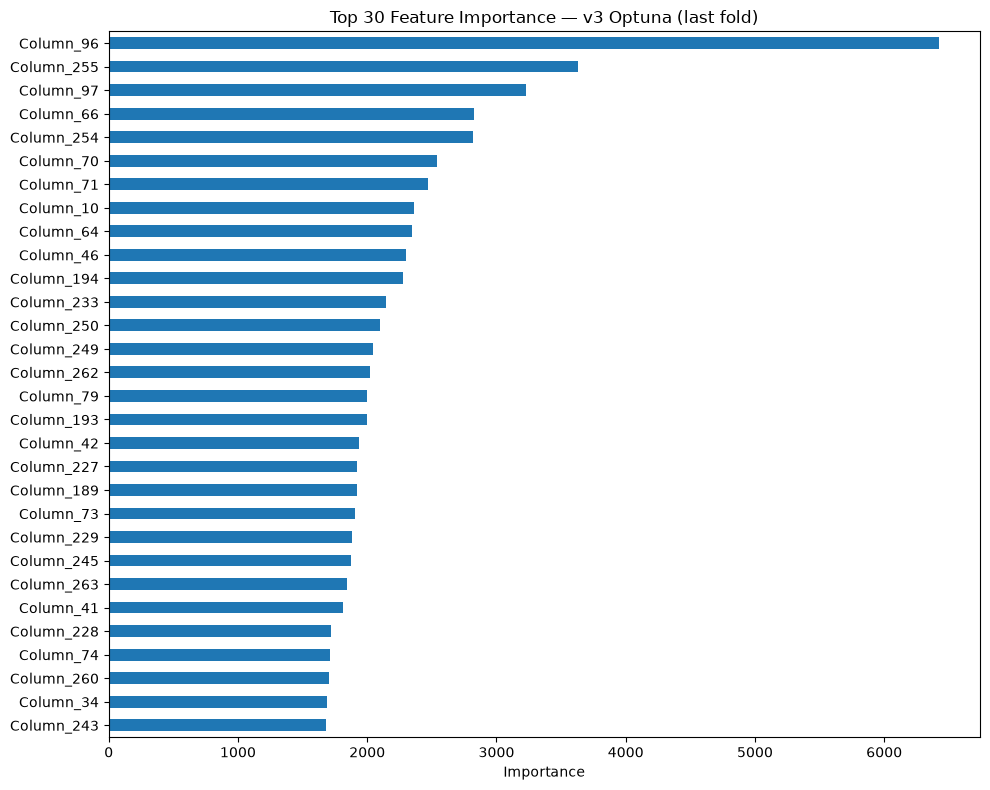

In [12]:
imp = pd.Series(model.feature_importances_, index=model.feature_name_)
top30 = imp.nlargest(30)

fig, ax = plt.subplots(figsize=(10, 8))
top30.sort_values().plot.barh(ax=ax)
ax.set_title('Top 30 Feature Importance — v3 Optuna (last fold)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 11. 제출 파일 생성

In [13]:
valid_submit = valid_Y_prob.copy()
wf_to_pred_v = dict(zip(wf_valid, valid_preds_folds))
valid_submit['C65'] = valid_submit['C64'].map(wf_to_pred_v)
valid_submit.to_csv('valid_Y_submit.csv', index=False)

test_submit = test_Y_prob.copy()
wf_to_pred_t = dict(zip(wf_test, test_preds_folds))
test_submit['C65'] = test_submit['C64'].map(wf_to_pred_t)
test_submit.to_csv('test_Y_submit.csv', index=False)

print("제출 파일 저장 완료")
print(f"  valid_Y_submit.csv — {valid_submit.shape}")
print(f"  test_Y_submit.csv  — {test_submit.shape}")

제출 파일 저장 완료
  valid_Y_submit.csv — (1990, 2)
  test_Y_submit.csv  — (1990, 2)


## 12. 일반화 점검

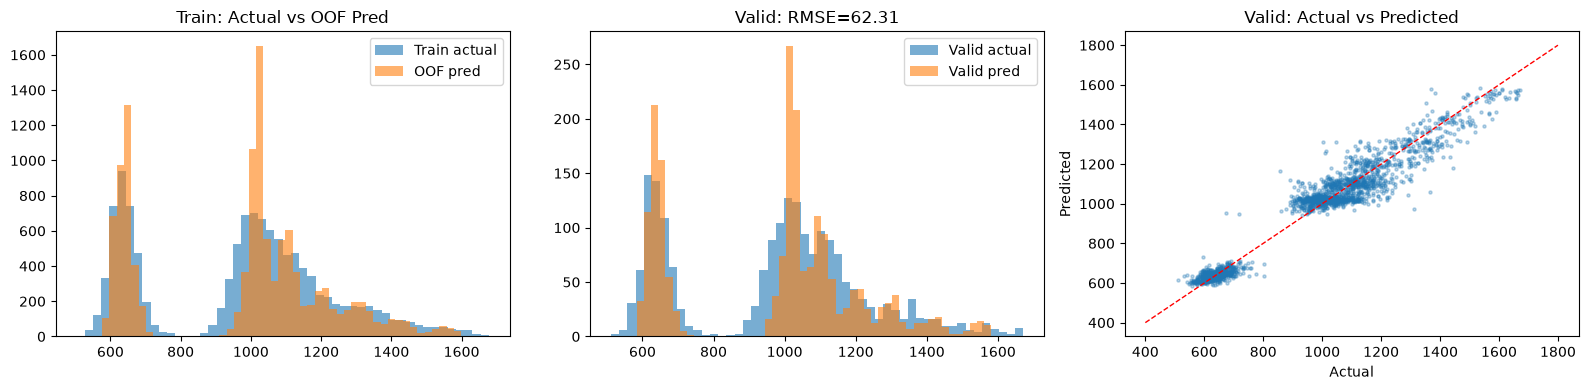

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=50, alpha=0.6, label='Train actual')
axes[0].hist(oof_preds, bins=50, alpha=0.6, label='OOF pred')
axes[0].set_title('Train: Actual vs OOF Pred')
axes[0].legend()

axes[1].hist(valid_answer, bins=50, alpha=0.6, label='Valid actual')
axes[1].hist(valid_preds_folds, bins=50, alpha=0.6, label='Valid pred')
axes[1].set_title(f'Valid: RMSE={valid_rmse:.2f}')
axes[1].legend()

axes[2].scatter(valid_answer, valid_preds_folds, s=5, alpha=0.3)
axes[2].plot([400, 1800], [400, 1800], 'r--', lw=1)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title('Valid: Actual vs Predicted')

plt.tight_layout()
plt.show()

## 13. 최적 파라미터 저장

In [15]:
import json

best_result = {
    'best_cv_rmse': study.best_value,
    'best_params': study.best_params,
    'valid_rmse': float(valid_rmse),
    'test_rmse': float(test_rmse),
    'n_trials': len(study.trials),
}

with open('optuna_best_params_v3.json', 'w') as f:
    json.dump(best_result, f, indent=2)

print("최적 파라미터 저장: optuna_best_params_v3.json")
print(json.dumps(best_result, indent=2))

최적 파라미터 저장: optuna_best_params_v3.json
{
  "best_cv_rmse": 62.20107676697408,
  "best_params": {
    "learning_rate": 0.005759888493722243,
    "num_leaves": 189,
    "max_depth": 10,
    "min_child_samples": 14,
    "subsample": 0.9668278565281413,
    "colsample_bytree": 0.6553280106987178,
    "reg_alpha": 4.25633536843975,
    "reg_lambda": 0.003098395985992314,
    "min_split_gain": 0.7576030443171627,
    "subsample_freq": 6
  },
  "valid_rmse": 62.314029042197475,
  "test_rmse": 60.51126658190436,
  "n_trials": 100
}
